In [42]:
from pathlib import Path

import numpy as np
import pandas as pd
from specparam import SpectralGroupModel

from pesco.experimental.clustering import (
    cluster_bands,
    cluster_peak_frequencies,
    find_k_with_no_peak,
    get_no_peak,
    order_clusters_by_peak,
)
from pesco.experimental.peak_testing import (
    compute_intervals,
    cutintervals,
    test_lobes,
    test_regions,
    test_regions_heatmap,
)
from pesco.experimental.plotting import (
    plot_cluster_brain,
    plot_clusters,
    plot_clusters_pair,
    plot_histogram,
    plot_lobes,
    plot_region_difference_heatmap,
    plot_region_difference_heatmap_pair,
    plot_regions,
)
from pesco.io import load_sources, prepare_psd
from pesco.pipeline import DatasetCtx
from pesco.preprocess import compute_psd, normalize_psd
from pesco.spectral import specparam2pandas

seed = 3
np.random.seed(seed)

PROJECT_DIR = Path("/Users/daniel/PhD/spectral-comparison/code/")
DATA_PATH_SOURCES = Path(f"{PROJECT_DIR}/data/Mantini2018")
DATA_PATH_IEEG = Path(f"{PROJECT_DIR}/data/Frauscher2018")

NO_PEAK_SUMMARY = "mean"
PLOT_SUMMARY = "median"

In [43]:
ieeg_raw = DatasetCtx(name="intracranial data (raw)")
ieeg_raw.f, ieeg_raw.psd = prepare_psd(
    DATA_PATH_IEEG / "WakefulnessMatlabFile.mat",
    DATA_PATH_IEEG / "RegionInformation.csv",
)
assert ieeg_raw.psd is not None

ieeg_raw.psd

,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,...,79.0,79.5,80.0,ChannelRegion,patient,mni_x,mni_y,mni_z,Region name,Lobe
channel,,,,,,,,,,,,,,,,,,,,,
GD001Lc_11,0.092947,0.114337,0.093374,0.067704,0.042922,0.040393,0.036007,0.034783,0.045677,0.039419,...,0.000052,0.000038,0.000037,31,1,-56.000000,-37.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lc_12,0.090270,0.147761,0.127372,0.075875,0.046717,0.039750,0.041112,0.037464,0.043440,0.036571,...,0.000090,0.000054,0.000046,31,1,-60.000000,-37.000000,-4.000000,'Middle temporal gyrus',Temporal
GD001Lc_13,0.079443,0.125797,0.091377,0.059805,0.054049,0.050969,0.035467,0.041534,0.044547,0.037190,...,0.000093,0.000053,0.000043,31,1,-63.000000,-37.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lc_14,0.166364,0.194635,0.096108,0.048454,0.039237,0.026046,0.020449,0.024757,0.030056,0.022768,...,0.000028,0.000018,0.000010,31,1,-68.000000,-38.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lo_1,0.140135,0.179327,0.118761,0.096757,0.064853,0.043011,0.050224,0.051905,0.043115,0.053518,...,0.000159,0.000152,0.000118,19,1,-1.000000,42.000000,-14.000000,'Medial frontal cortex',Frontal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NG110RG614,0.034908,0.102428,0.130893,0.076009,0.046062,0.041571,0.041874,0.038723,0.048300,0.065662,...,0.000025,0.000015,0.000013,6,110,64.958333,-6.500000,13.666667,'Postcentral gyrus (including medial segment)',Parietal
NG110RG64,0.039227,0.089204,0.113189,0.090483,0.061624,0.053920,0.063370,0.060249,0.050575,0.080074,...,0.000016,0.000015,0.000012,21,110,48.464286,27.464286,-1.285714,'Frontal operculum',Frontal
NG110RG65,0.067036,0.150605,0.133164,0.077352,0.071302,0.058644,0.048273,0.045799,0.040558,0.038862,...,0.000025,0.000017,0.000019,21,110,52.535714,15.035714,-0.214286,'Frontal operculum',Frontal


## Remove aperiodic 1/f (knee) — Afnan et al. 2023

FOOOF / specparam, knee mode, params from Afnan2023 (Table/§2.10):
`freq_range=[0.5, 80]`, `peak_width_limits=[1, 8]`, `max_n_peaks=8`,
`peak_threshold=3.0`, `aperiodic_mode="knee"`. Subtract aperiodic in log-log,
back-transform to linear PSD for downstream clustering.

In [44]:
freqs = np.asarray(ieeg_raw.f, dtype=float)
psd_mat = ieeg_raw.psd.iloc[:, : len(freqs)].to_numpy(dtype=float)

Fitting model across 1772 power spectra.
Fitting model across 1772 power spectra.
                                                                                                  
                           GROUP SPECTRAL MODEL RESULTS (1772 spectra)                            
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 1-80 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                                Aperiodic Parameters ('knee' mode)                                
                         offset   - Min:  -0.82, Max:   9.88, Mean:  3.03                         
                 knee     - Min:  -0.73, Max: 291623978429.89, Mean: 308740489.88                 
                         ex

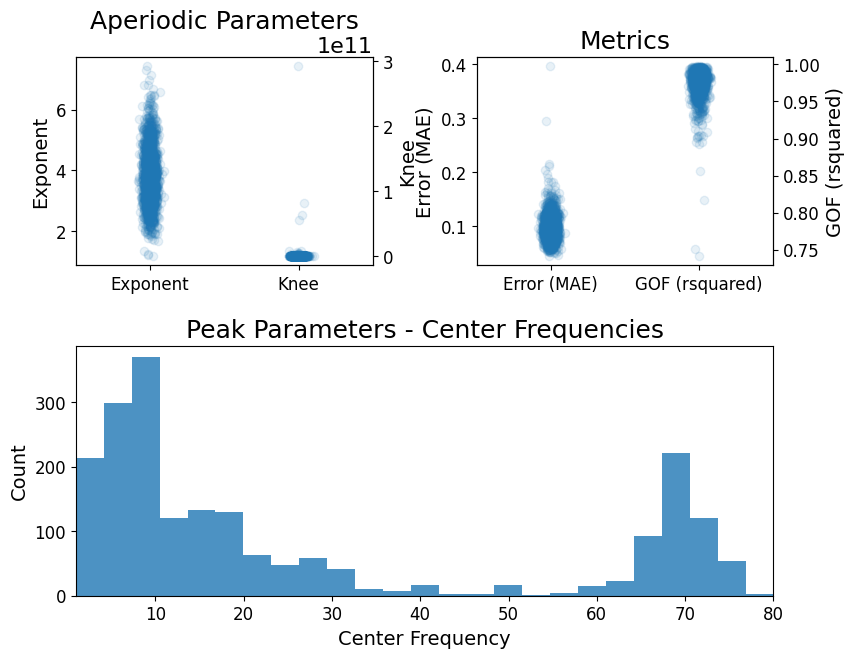

In [45]:
FREQ_RANGE = (1.0, 80.0)
R2_THRESHOLD = 0.9


fg = SpectralGroupModel(
    peak_width_limits=[1, 8],
    max_n_peaks=8,
    peak_threshold=3.0,
    aperiodic_mode="knee",
)
fg.fit(freqs, psd_mat, freq_range=list(FREQ_RANGE), n_jobs=1)
fg.report()

In [ ]:
df = specparam2pandas(fg)
df["knee_freq"] = df["knee"] ** (1.0 / df["exponent"])

,ID,offset,knee,exponent,error_mae,gof_rsquared,CF,PW,BW
0,0,3.439636,71172.516353,3.876840,0.081606,0.982765,15.034249,0.464457,3.416452
1,1,3.822784,187267.047003,4.061919,0.082546,0.981395,14.918342,0.415648,3.000262
2,2,3.591213,103733.111914,3.914094,0.079937,0.982831,14.888375,0.415486,3.207899
3,3,3.808251,218400.265512,4.294227,0.103902,0.977459,15.163526,0.717778,3.700885
4,4,1.632262,768.556555,2.593561,0.096368,0.956408,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2600,1769,3.226475,30956.872037,4.096813,0.075504,0.989806,7.540846,0.555584,1.761963
2601,1769,3.226475,30956.872037,4.096813,0.075504,0.989806,70.648067,0.413428,8.000000
2602,1770,3.103414,24743.439404,3.695472,0.066890,0.989823,7.412737,0.289553,2.212333
2603,1770,3.103414,24743.439404,3.695472,0.066890,0.989823,70.292936,0.329625,7.349074


In [47]:



mask = (freqs >= FREQ_RANGE[0]) & (freqs <= FREQ_RANGE[1])
f_fit = freqs[mask]

# specparam v2: r.aperiodic_fit holds params [offset, knee, exponent] in knee mode.
# Reconstruct curve in log10 power: offset - log10(knee + f^exponent).
ap_params = np.array([r.aperiodic_fit for r in fg.results], dtype=float)
offset, knee, exponent = ap_params[:, 0], ap_params[:, 1], ap_params[:, 2]
ap_log = offset[:, None] - np.log10(
    knee[:, None] + f_fit[None, :] ** exponent[:, None]
)

log_psd_fit = np.log10(psd_mat[:, mask])
osc_log = log_psd_fit - ap_log
#osc_lin = 10**osc_log

r2 = np.array([r.metrics["gof_rsquared"] for r in fg.results])
print(f"Channels: {len(r2)} | R² median={np.nanmedian(r2):.3f} | "
      f"good (R²>={R2_THRESHOLD}): {(r2 >= R2_THRESHOLD).sum()}")

Channels: 1772 | R² median=0.981 | good (R²>=0.9): 1765


Bad fits (R² < 0.9): 7 / 1772


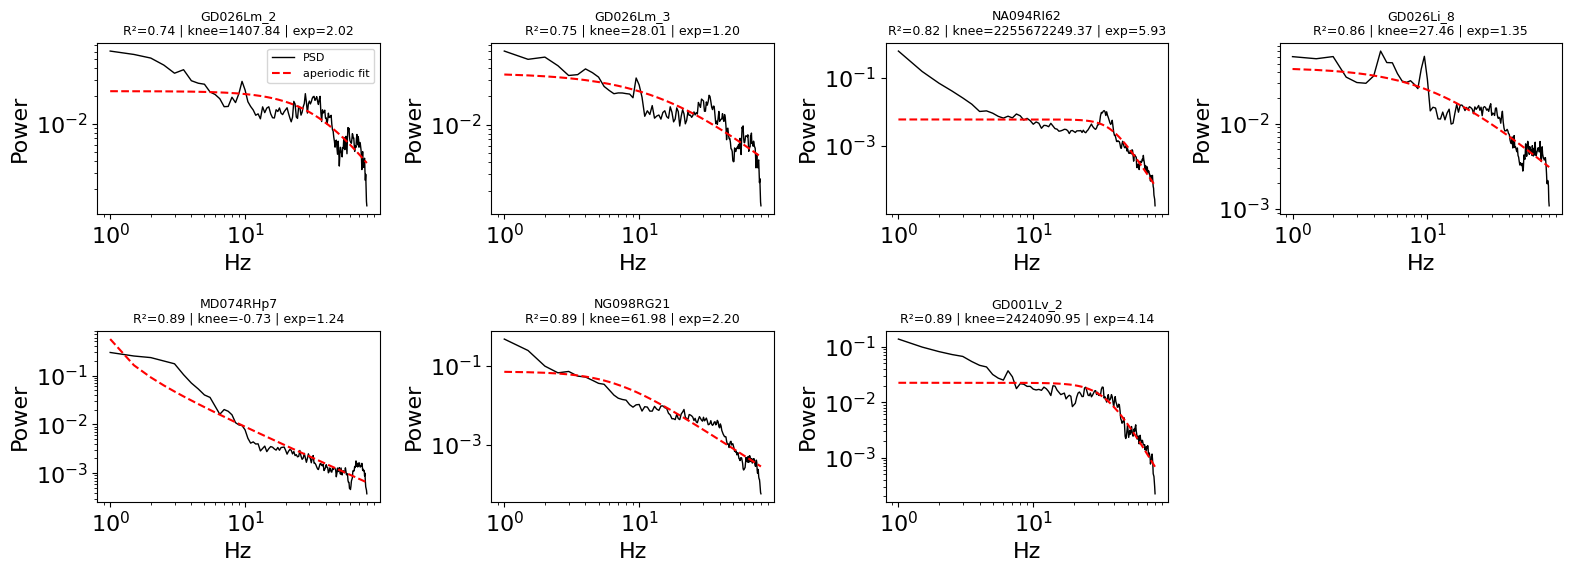

In [19]:
import matplotlib.pyplot as plt

bad_idx = np.where(r2 < R2_THRESHOLD)[0]
print(f"Bad fits (R² < {R2_THRESHOLD}): {len(bad_idx)} / {len(r2)}")

N_SHOW = min(12, len(bad_idx))
if N_SHOW > 0:
    show_idx = bad_idx[np.argsort(r2[bad_idx])][:N_SHOW]
    ncols = 4
    nrows = int(np.ceil(N_SHOW / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
    ch_names = ieeg_raw.psd.index.to_numpy()

    for ax, i in zip(axes.flat, show_idx):
        ax.loglog(f_fit, psd_mat[i, mask], color="black", lw=1, label="PSD")
        ax.loglog(f_fit, 10 ** ap_log[i], color="red", lw=1.5, ls="--", label="aperiodic fit")
        ax.set_title(
            f"{ch_names[i]}\nR²={r2[i]:.2f} | knee={knee[i]:.2f} | exp={exponent[i]:.2f}",
            fontsize=9,
        )
        ax.set_xlabel("Hz")
        ax.set_ylabel("Power")

    for ax in axes.flat[N_SHOW:]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=8)
    fig.tight_layout()
    plt.show()

In [20]:
# `ieeg` = aperiodic-removed (knee) PSD. `ieeg_raw` retained for reference.
meta_cols = ieeg_raw.psd.columns[len(freqs):]
osc_df = pd.DataFrame(osc_lin, index=ieeg_raw.psd.index, columns=f_fit)
osc_df = osc_df.join(ieeg_raw.psd[meta_cols])

ieeg = DatasetCtx(name="intracranial_data_1f_removed")
ieeg.f = f_fit
ieeg.psd = osc_df
ieeg.psd

,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,...,79.0,79.5,80.0,ChannelRegion,patient,mni_x,mni_y,mni_z,Region name,Lobe
channel,,,,,,,,,,,,,,,,,,,,,
GD001Lc_11,2.957111,2.415070,1.751390,1.110643,1.045716,0.932918,0.902321,1.187005,1.026822,0.844565,...,0.430015,0.319407,0.323988,31,1,-56.000000,-37.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lc_12,4.161386,3.587257,2.137036,1.315968,1.119981,1.158833,1.056662,1.226327,1.033755,0.997858,...,0.693267,0.424299,0.370893,31,1,-60.000000,-37.000000,-4.000000,'Middle temporal gyrus',Temporal
GD001Lc_13,3.344882,2.429746,1.590385,1.437630,1.356193,0.944259,1.106779,1.188589,0.994048,0.975392,...,0.642236,0.375021,0.311783,31,1,-63.000000,-37.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lc_14,6.610376,3.264173,1.645787,1.332898,0.885054,0.695205,0.842307,1.023782,0.776813,0.749147,...,0.610825,0.402859,0.238224,31,1,-68.000000,-38.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lo_1,3.218286,2.136497,1.747815,1.178643,0.788214,0.930351,0.974401,0.822482,1.040318,1.173965,...,0.311690,0.302663,0.238495,19,1,-1.000000,42.000000,-14.000000,'Medial frontal cortex',Frontal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NG110RG614,1.877662,2.402717,1.399457,0.852737,0.776408,0.792314,0.746066,0.953162,1.335910,2.479623,...,0.617026,0.384561,0.336171,6,110,64.958333,-6.500000,13.666667,'Postcentral gyrus (including medial segment)',Parietal
NG110RG64,1.457902,1.850237,1.479835,1.008967,0.884647,1.043267,0.997187,0.843610,1.350289,1.325911,...,0.701746,0.680317,0.527498,21,110,48.464286,27.464286,-1.285714,'Frontal operculum',Frontal
NG110RG65,2.767806,2.447623,1.422316,1.312145,1.080848,0.891991,0.849625,0.756760,0.731026,0.917547,...,0.894464,0.621788,0.693569,21,110,52.535714,15.035714,-0.214286,'Frontal operculum',Frontal


In [21]:
k, ieeg.psd_clust, ieeg.smal = find_k_with_no_peak(
    ieeg.psd,
    k_range=range(2, 16),
    feature_cols=ieeg.f,
    summary=NO_PEAK_SUMMARY,
    random_seed=seed,
)

print(f"selected k={k}, no-peak cluster(s): {ieeg.smal}")

no_peak_df, no_peak_center = get_no_peak(
    ieeg.psd_clust, ieeg.smal, feature_cols=ieeg.f, summary=NO_PEAK_SUMMARY,
)

assert no_peak_df is not None and no_peak_center is not None
ieeg.no_peak_df = no_peak_df
ieeg.no_peak_center = no_peak_center

selected k=7, no-peak cluster(s): [1]


In [22]:
ieeg.peaks = cluster_peak_frequencies(
    ieeg.psd_clust,
    ieeg.f,
    summary=PLOT_SUMMARY,
    baseline=ieeg.no_peak_center,
    freq_range=(1.0, 80.0),
    feature_cols=ieeg.f,
    no_peak=ieeg.smal,
)
print(ieeg.peaks)

{0: 23.0, 1: None, 2: 1.0, 3: 6.0, 4: 14.5, 5: 1.0, 6: 9.0}


In [23]:
ieeg.name

'intracranial_data_1f_removed'

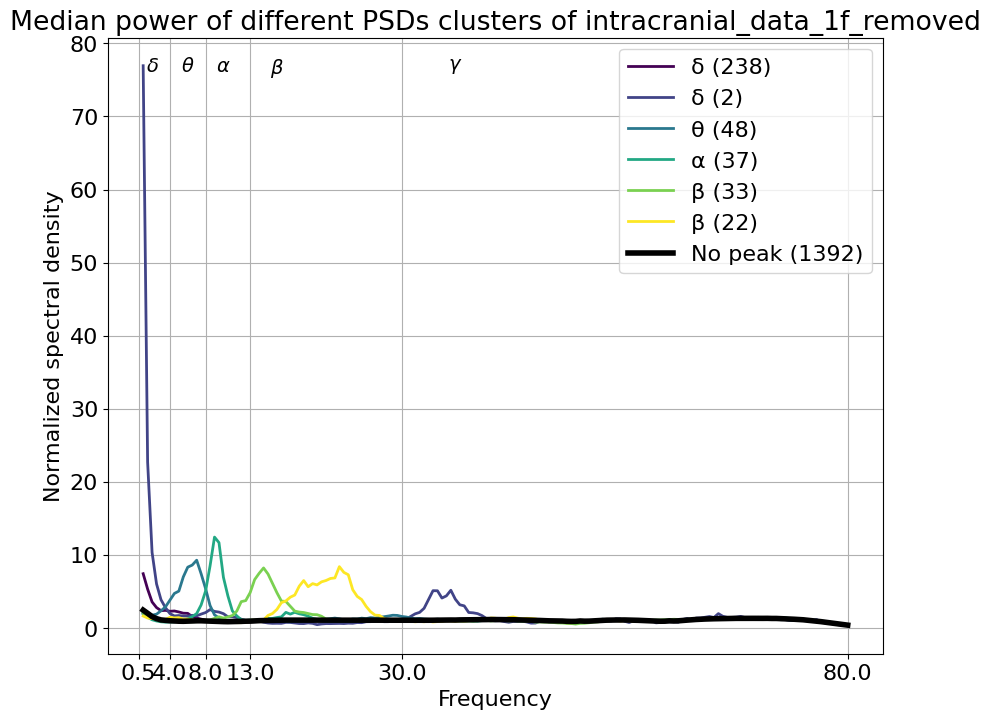

In [25]:
fig, _ = plot_clusters(
    ieeg.psd_clust,
    ieeg.f,
    ieeg.name,
    ieeg.smal,
    nopeak=ieeg.smal[0] if ieeg.smal else None,
    summary=PLOT_SUMMARY,
    log_y=False,
    log_x=False,
    order_by_peak=True,
    peak_baseline=ieeg.no_peak_center,
    peak_freq_range=(1.0, 80.0),
    feature_cols=ieeg.f,
    label_by_band=True,
)
fig.savefig(f"images/{ieeg.name}_clusters.png", dpi=600, bbox_inches="tight")

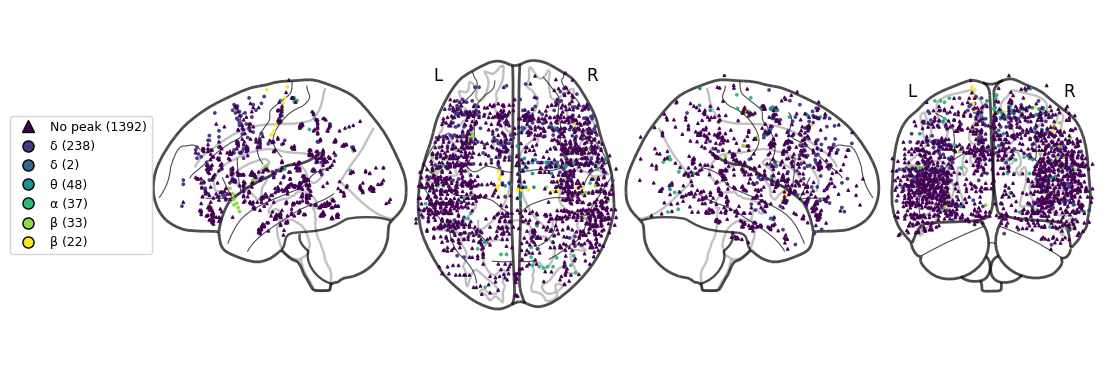

In [26]:
pos = ieeg.psd_clust[["mni_x", "mni_y", "mni_z"]].to_numpy()
labels = ieeg.psd_clust["clusters"].to_numpy()

order = list(ieeg.smal) + order_clusters_by_peak(
    ieeg.psd_clust,
    ieeg.f,
    summary=PLOT_SUMMARY,
    exclude=ieeg.smal,
    baseline=ieeg.no_peak_center,
    freq_range=(1.0, 80.0),
    feature_cols=ieeg.f,
)
band_names = cluster_bands(ieeg.peaks)

plot_cluster_brain(
    pos,
    labels,
    label_names=band_names,
    label_order=order,
    label_markers={k: "^" for k in (ieeg.smal or [])},
    node_size=3,
    alpha=0.95,
    legend_bbox=(-0.15, 0.5),
    output_path=f"images/{ieeg.name}_cluster_brain.svg",)

In [15]:
ieeg.colbin, _ = cutintervals(ieeg.f)
ieeg.regional_diff = test_regions_heatmap(
    no_peak_df=ieeg.no_peak_df,
    psd=ieeg.psd,
    colbin=ieeg.colbin,
)
ieeg.sig_lobes = test_lobes(ieeg.no_peak_df, ieeg.psd, ieeg.colbin)
ieeg.sig_regions = test_regions(ieeg.no_peak_df, ieeg.psd, ieeg.colbin)

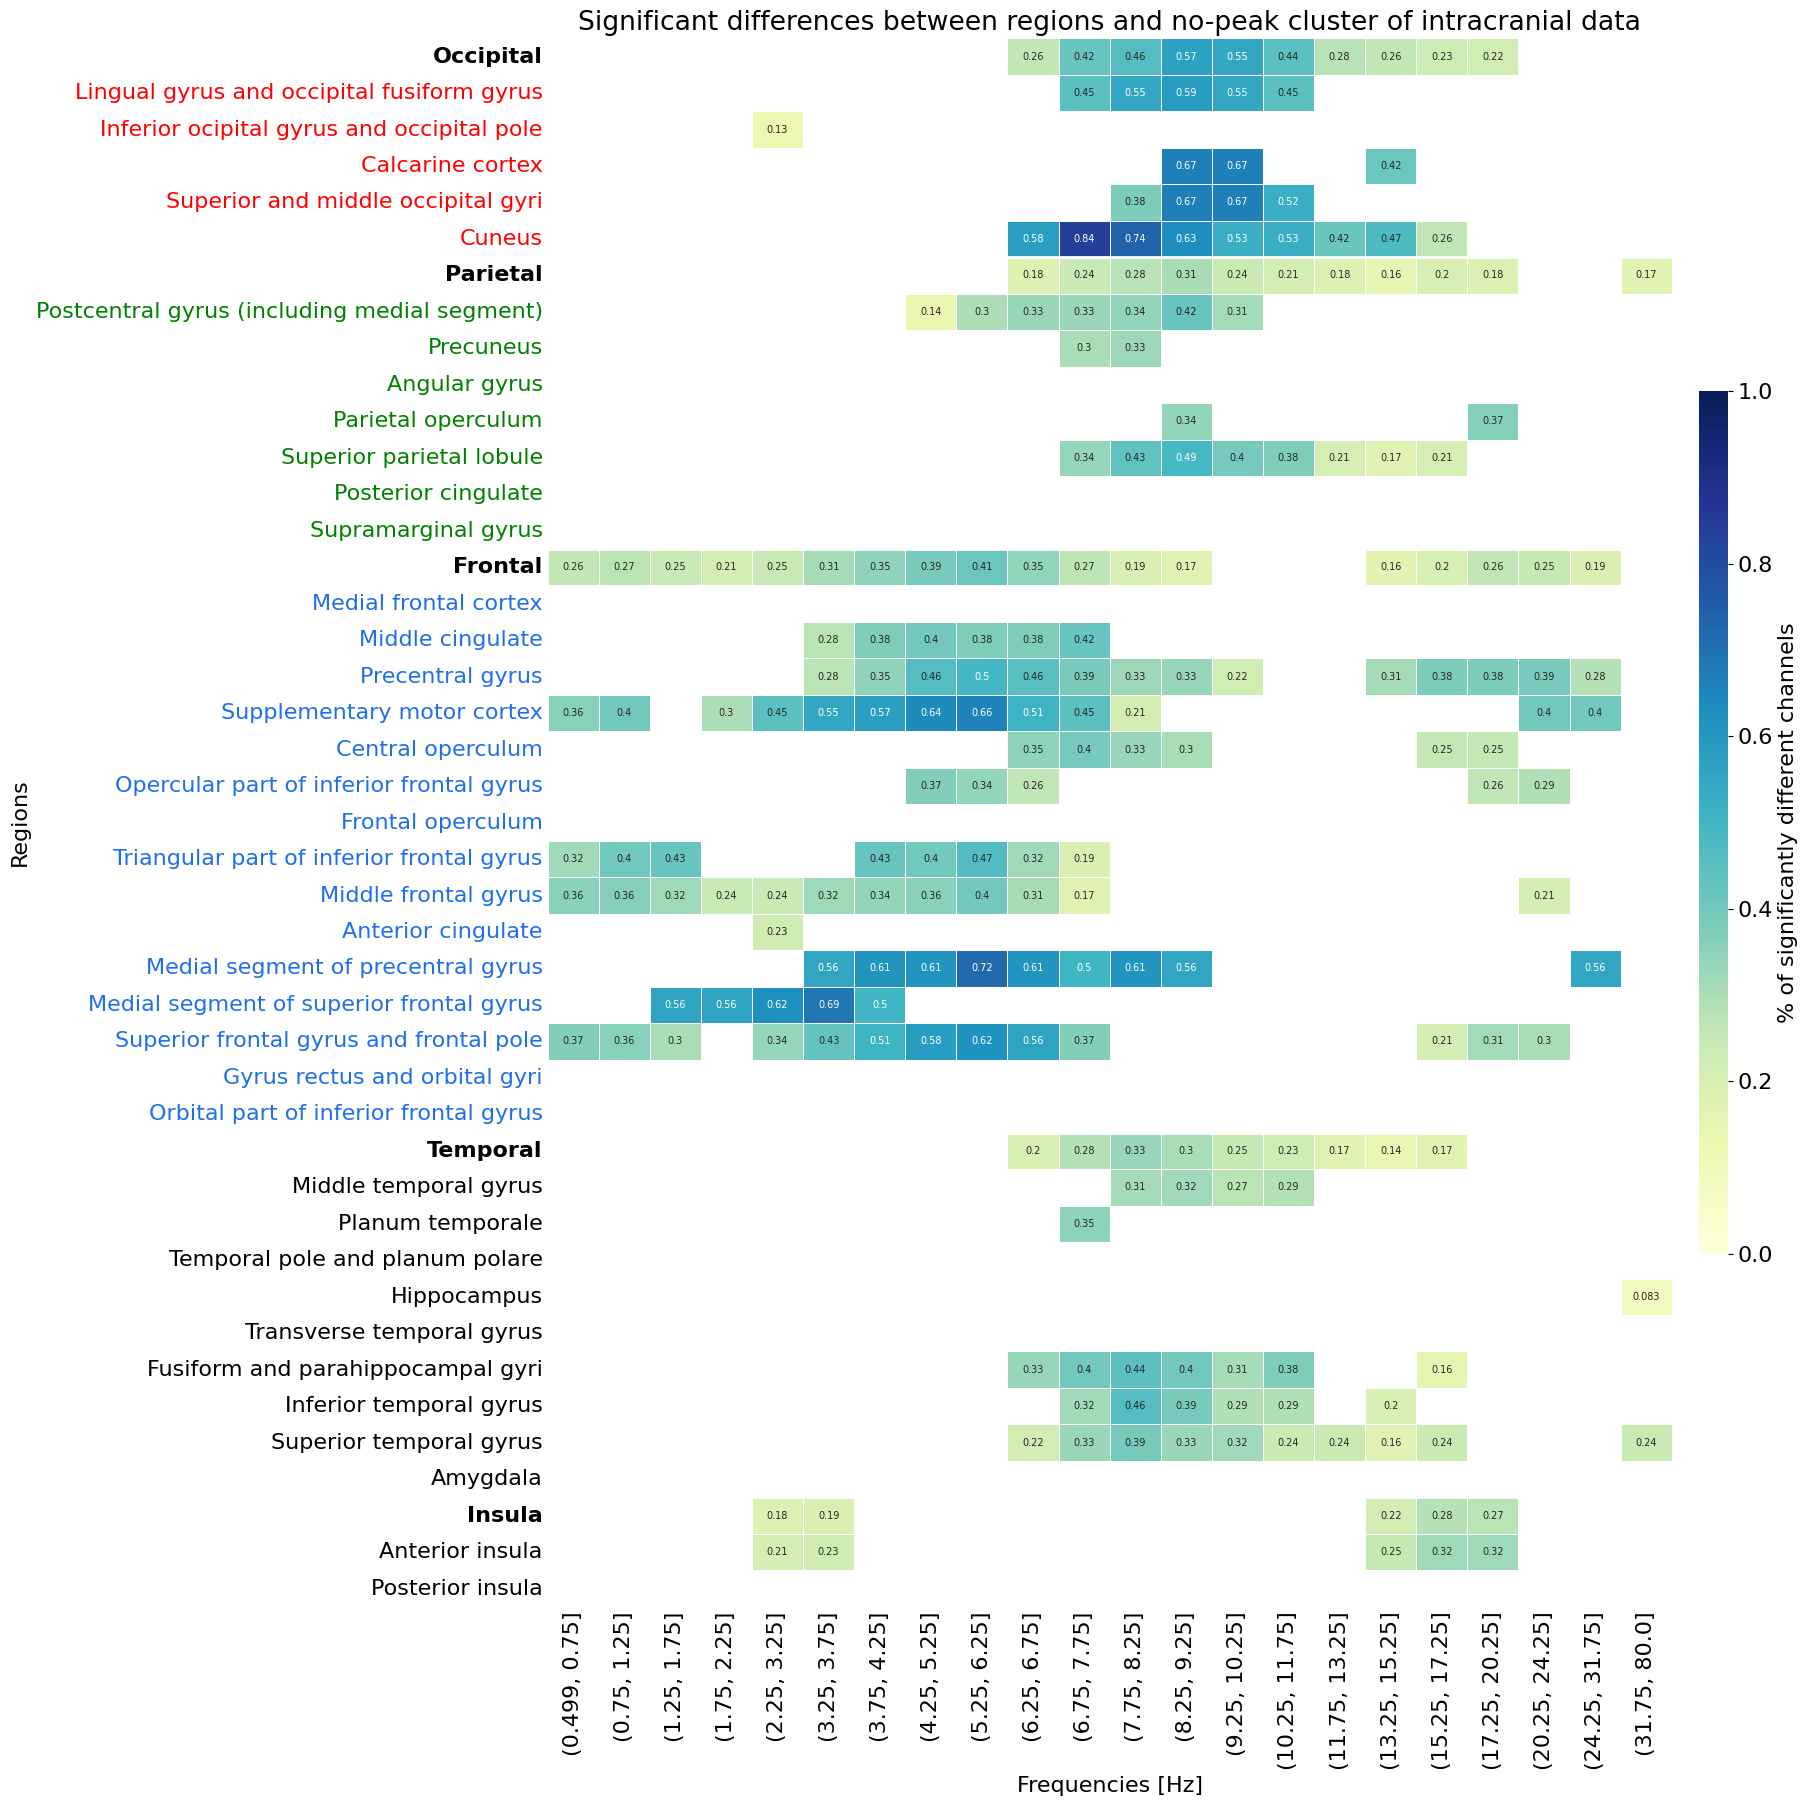

In [ ]:
fig, ax = plot_region_difference_heatmap(
    ieeg.regional_diff,
    title=f"Significant differences between regions and no-peak cluster of {ieeg.name}",
    output_path=f"images/{ieeg.name}_all_regional_differences.png",
    annot_fontsize=7,
)

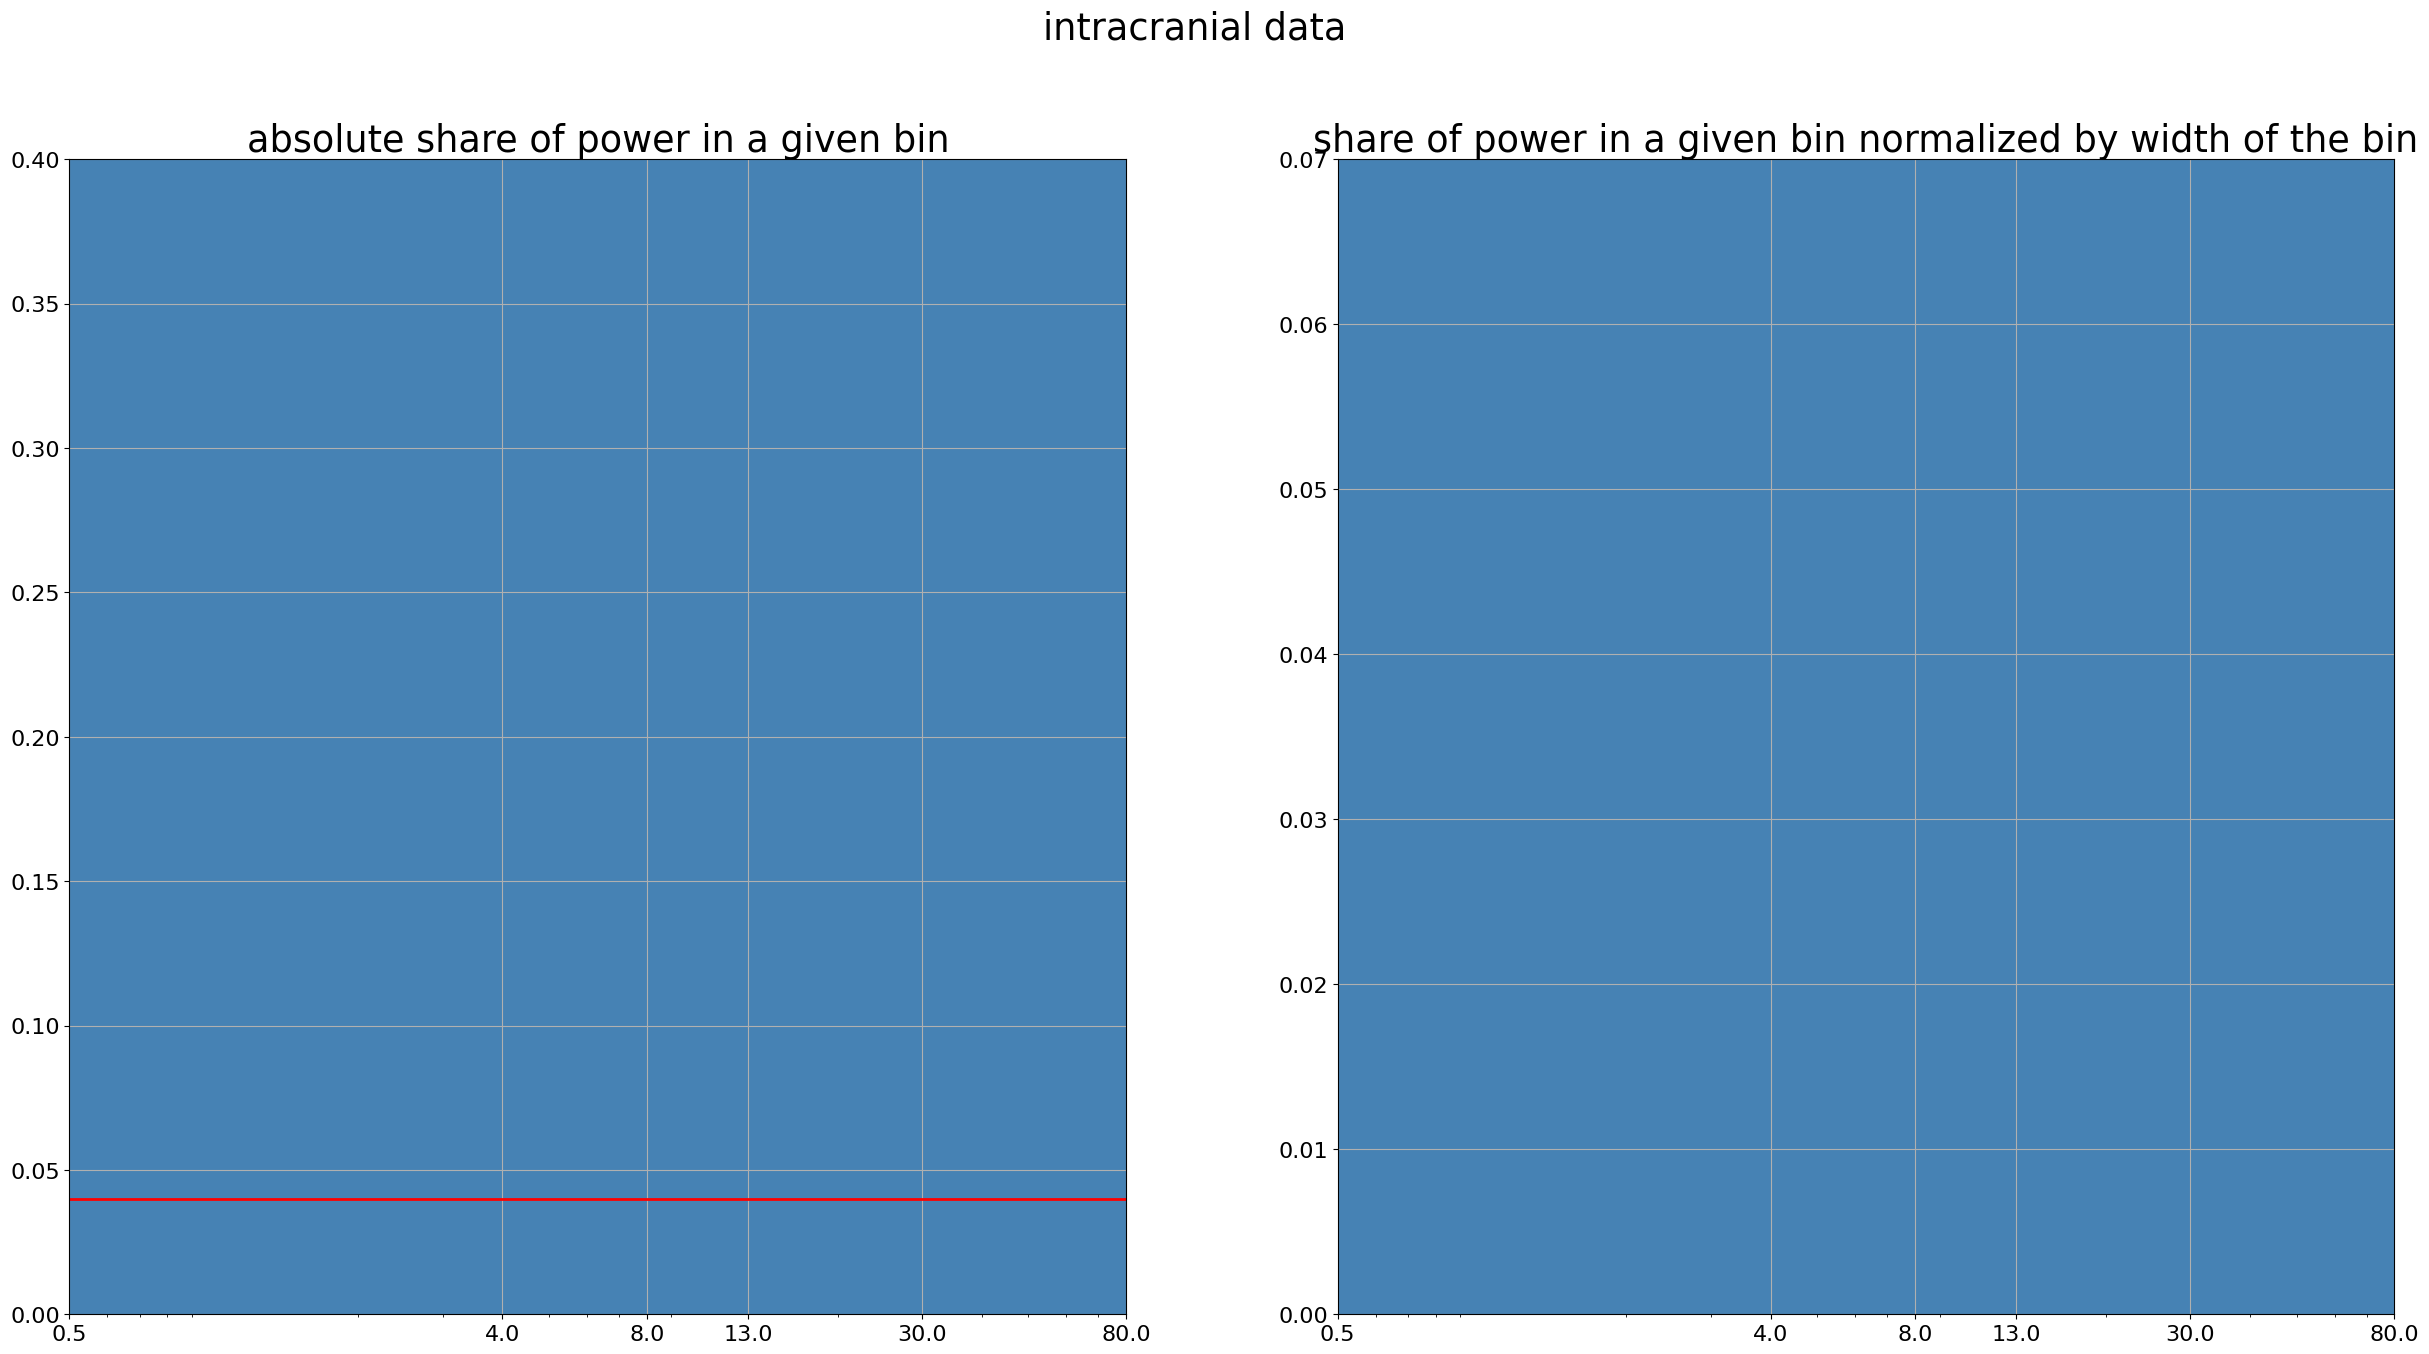

In [ ]:
fig, _ = plot_histogram(ieeg.psd, ieeg.colbin, ieeg.name, summary=PLOT_SUMMARY)
fig.savefig(f"images/{ieeg.name}_powershare.png", dpi=600, bbox_inches="tight")

In [ ]:
fig, axes = plot_lobes(
    ieeg.psd_clust, ieeg.psd, ieeg.f, ieeg.smal, ieeg.name, ieeg.sig_lobes,
    summary=PLOT_SUMMARY, tick_labelsize=12,subplot_height_ratio=0.6, font_size=14
)
fig.savefig(f"images/{ieeg.name}_lobar_differences.svg")